# Wstęp do Uczenia Maszynowego - Projekt I
## Etap: Drugi Kamień Milowy 
### Autorzy: Krzysztof Osiński, Jakub Miszczak

## Import packages

In [20]:
import pandas as pd
import numpy as np
import sklearn 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
np.random.seed(23)
import zipfile

# Fraud Detection Transactions Dataset - Feature Extraction

In [21]:
zip_path = "fraud-detection-transactions-dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open("synthetic_fraud_dataset.csv") as file:
        df = pd.read_csv(file)

In [22]:
df.columns = df.columns.str.replace(" ","_").str.lower()
df1 = df.drop(['transaction_id','user_id'],axis='columns')
df1['timestamp'] = pd.to_datetime(df1['timestamp'])

In [23]:
X = df1.drop('fraud_label', axis='columns')
Y = df1['fraud_label']

from sklearn.preprocessing import MinMaxScaler

scaled_columns = X.select_dtypes(['int64', 'float64']).columns

scaler = MinMaxScaler()

X[scaled_columns] = scaler.fit_transform(X[scaled_columns])
X.describe()

,transaction_amount,timestamp,account_balance,ip_address_flag,previous_fraudulent_activity,daily_transaction_count,avg_transaction_amount_7d,failed_transaction_count_7d,card_age,transaction_distance,risk_score,is_weekend
count,50000.0000,50000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000
mean,0.0847,2023-07-02 12:47:11.063999744,0.5004,0.0502,0.0984,0.4989,0.5006,0.5009,0.5000,0.4998,0.5015,0.2996
min,0.0000,2023-01-01 00:01:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0244,2023-04-02 03:35:30,0.2498,0.0000,0.0000,0.2308,0.2492,0.2500,0.2479,0.2513,0.2539,0.0000
50%,0.0593,2023-07-02 14:00:00,0.5014,0.0000,0.0000,0.4615,0.5022,0.5000,0.5000,0.4981,0.5022,0.0000
75%,0.1183,2023-10-01 07:13:00,0.7499,0.0000,0.0000,0.7692,0.7511,0.7500,0.7521,0.7493,0.7495,1.0000
max,1.0000,2023-12-31 23:50:00,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
std,0.0841,NaN,0.2891,0.2184,0.2979,0.3107,0.2885,0.3536,0.2899,0.2884,0.2878,0.4581


## Variance Inflation Factor (VIF)
Wartość VIF w okolicach 1 mówi o bardzo małej współliniowości cech.

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df):
    vif_df = pd.DataFrame()
    vif_df['Column'] = df.columns
    vif_df['VIF'] = [variance_inflation_factor(df.values,i) for i in range(df.shape[1])]
    return vif_df

In [25]:
calculate_vif(X[scaled_columns])

,Column,VIF
0,transaction_amount,1.9272
1,account_balance,3.4615
2,ip_address_flag,1.0504
3,previous_fraudulent_activity,1.1036
4,daily_transaction_count,3.1596
5,avg_transaction_amount_7d,3.4722
6,failed_transaction_count_7d,2.7309
7,card_age,3.4294
8,transaction_distance,3.4529
9,risk_score,3.4787


## Weight of Evidence (WOE)

In [26]:
# Funkcja do policzenia WOE i IV dla naszych cech
def calculate_woe_iv(df, feature, target):
    
    grouped = df.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad']=grouped['total']-grouped['good']
    
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    
    grouped['good_score'] = grouped['good'] / total_good
    grouped['bad_score'] = grouped['bad'] / total_bad
    grouped['woe'] = np.log(grouped['good_score']/ grouped['bad_score'])
    grouped['iv'] = (grouped['good_score'] -grouped['bad_score'])*grouped['woe']
    
    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)
    
    total_iv = grouped['iv'].sum()
    
    return grouped, total_iv

In [27]:
iv_values = {}

discrete_columns = ['ip_address_flag', 'previous_fraudulent_activity', 'daily_transaction_count', 
                                                   'failed_transaction_count_7d', 'is_weekend', 'hour', 'weekday', 'is_night',
                                                  'is_large_transaction', 'transaction_bin', 'high_failed_tx_flag', 
                                                   'high_transaction_distance', 'high_sqrt_risk_score', 'low_balance_flag']
# Liczymy IV 
for feature in X.columns:
    # Jeśli kolumna kategoryczna lub dyskretna to względem kategorii
    if X[feature].dtype == 'object' or feature in discrete_columns:
        _, iv = calculate_woe_iv(pd.concat([X, Y],axis=1), feature, 'fraud_label' )
    # Jeśli kolumna numeryczna to dzielimy na biny i liczymy względem binów
    else:
        X_binned = pd.cut(X[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X_binned, Y],axis=1), feature, 'fraud_label' )
    iv_values[feature] = iv
    
# Eleganckie zapisanie wyników 
pd.set_option('display.float_format', lambda x: '{:.4f}'.format(x))

iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)

## Information Value (IV)
IV < 0.02  --> brak wartości predykcyjnej

0.3 <= IV < 0.5  --> silna wartość predykcyjna

IV >= 0.5  --> bardzo silna wartość predykcyjna (trzeba uważać na overfitting)

In [28]:
iv_df

,Feature,IV
11,failed_transaction_count_7d,0.5995
16,risk_score,0.4483
9,daily_transaction_count,0.0009
3,account_balance,0.0009
14,transaction_distance,0.0009
13,card_age,0.0005
2,timestamp,0.0004
10,avg_transaction_amount_7d,0.0003
15,authentication_method,0.0003
5,location,0.0002


### Spostrzeżenia
Na tym etapie wartość predykcyjną wykazują jedynie cechy 'failed_transaction_count_7d' i 'risk_score'.

## New Features
Teraz poprzez interakcje między zmiennymi i transformacje zmiennych spróbujmy znaleźć więcej ciekawych cech.

In [29]:
# Tworzenie nowych cech
df1['failed_tx_risk_interaction'] = df1['failed_transaction_count_7d'] * df1['risk_score']
df1['amount_risk_interaction'] = df1['transaction_amount'] * df1['risk_score']
df1['balance_to_avg_tx_ratio'] = df1['account_balance'] / df1['avg_transaction_amount_7d']
df1['low_balance_flag'] = (df1['account_balance'] < df1['transaction_amount']).astype(int)

# Detekcja wartości odstających - flagi
df1['high_transaction_distance'] = (df1['transaction_distance'] > df1['transaction_distance'].quantile(0.95)).astype(int)
df1['high_failed_tx_flag'] = (df1['failed_transaction_count_7d'] > 3).astype(int)
df1["is_large_transaction"] = (df1["transaction_amount"] > df1["transaction_amount"].quantile(0.95)).astype(int)

# Transformacje matematyczne
df1['log_transaction_amount'] = np.log1p(df1['transaction_amount'])
df1["sqrt_transaction_amount"] = np.sqrt(df1["transaction_amount"])
df1['log_account_balance'] = np.log1p(df1['account_balance'])
df1['sqrt_risk_score'] = np.sqrt(df1['risk_score'])
df1['sqrt_transaction_distance'] = np.sqrt(df1['transaction_distance'])  

df1['high_sqrt_risk_score'] = (df1['sqrt_risk_score'] > 0.9).astype(int)

# Ekstrakcja cech czasowych
df1['hour'] = df1['timestamp'].dt.hour
df1['weekday'] = df1['timestamp'].dt.dayofweek
df1['is_night'] = ((df1['hour'] >= 0) & (df1['hour'] <= 6)).astype(int)

# One-hot encoding dla cech kategorycznych
categorical_features = ['authentication_method', 'device_type', 'card_type', 'transaction_type', 'merchant_category', 'location']
df1 = pd.get_dummies(df1, columns=categorical_features, drop_first=True)


## Histograms for some new features

In [30]:
features = ['sqrt_risk_score', 'failed_tx_risk_interaction',
            'failed_transaction_count_7d', 'risk_score']

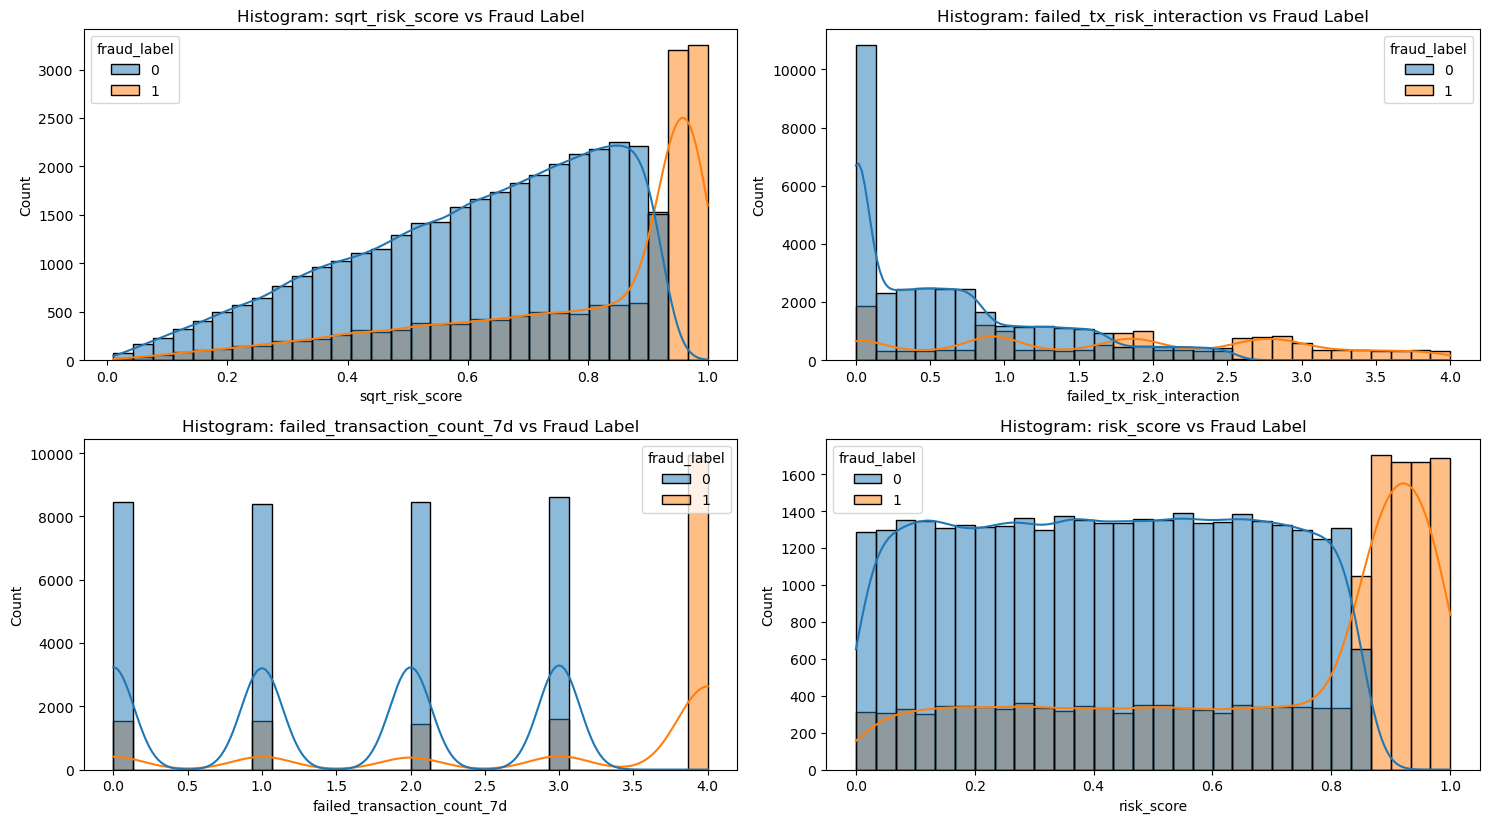

In [31]:
plt.figure(figsize=(15, 12))

# Histogramy
for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data=df1, x=feature, hue='fraud_label', kde=True, bins=30, alpha=0.5)
    plt.title(f'Histogram: {feature} vs Fraud Label')

plt.tight_layout()
plt.show()

### Scaling

In [32]:
X2 = df1.drop('fraud_label', axis='columns')
scaled_columns = X2.select_dtypes(['int64', 'float64']).columns

scaler = MinMaxScaler()

X2[scaled_columns] = scaler.fit_transform(X2[scaled_columns])

In [44]:
X2.describe().T

,count,mean,min,25%,50%,75%,max,std
transaction_amount,50000.0000,0.0847,0.0000,0.0244,0.0593,0.1183,1.0000,0.0841
timestamp,50000,2023-07-02 12:47:11.063999744,2023-01-01 00:01:00,2023-04-02 03:35:30,2023-07-02 14:00:00,2023-10-01 07:13:00,2023-12-31 23:50:00,NaN
account_balance,50000.0000,0.5004,0.0000,0.2498,0.5014,0.7499,1.0000,0.2891
ip_address_flag,50000.0000,0.0502,0.0000,0.0000,0.0000,0.0000,1.0000,0.2184
previous_fraudulent_activity,50000.0000,0.0984,0.0000,0.0000,0.0000,0.0000,1.0000,0.2979
daily_transaction_count,50000.0000,0.4989,0.0000,0.2308,0.4615,0.7692,1.0000,0.3107
avg_transaction_amount_7d,50000.0000,0.5006,0.0000,0.2492,0.5022,0.7511,1.0000,0.2885
failed_transaction_count_7d,50000.0000,0.5009,0.0000,0.2500,0.5000,0.7500,1.0000,0.3536
card_age,50000.0000,0.5000,0.0000,0.2479,0.5000,0.7521,1.0000,0.2899
transaction_distance,50000.0000,0.4998,0.0000,0.2513,0.4981,0.7493,1.0000,0.2884


## IV of New Features

In [34]:
iv_values2 = {}
for feature in X2.columns:
    # Jeśli kolumna kategoryczna lub dyskretna to względem kategorii
    if X2[feature].dtype == 'object' or feature in discrete_columns:
        _, iv = calculate_woe_iv(pd.concat([X2, Y],axis=1), feature, 'fraud_label' )
    # Jeśli kolumna numeryczna to dzielimy na biny i liczymy względem binów
    else:
        X2_binned = pd.cut(X2[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X2_binned, Y],axis=1), feature, 'fraud_label' )
    iv_values2[feature] = iv
    
# Eleganckie zapisanie wyników 
pd.set_option('display.float_format', lambda x: '{:.4f}'.format(x))

iv_df2 = pd.DataFrame(list(iv_values2.items()), columns=['Feature', 'IV'])
iv_df2 = iv_df2.sort_values(by='IV', ascending=False)
iv_df2

,Feature,IV
22,sqrt_risk_score,1.3834
24,high_sqrt_risk_score,1.3605
12,failed_tx_risk_interaction,0.8859
7,failed_transaction_count_7d,0.5995
17,high_failed_tx_flag,0.5987
10,risk_score,0.4483
13,amount_risk_interaction,0.1035
25,hour,0.0023
23,sqrt_transaction_distance,0.0010
5,daily_transaction_count,0.0009


## Correlations with target feature

In [35]:
X_numeric = X2.select_dtypes(include=['number'])
correlations = X_numeric.corrwith(Y).sort_values(ascending=False)
print(correlations)

high_failed_tx_flag             0.7245
high_sqrt_risk_score            0.5358
failed_tx_risk_interaction      0.5297
failed_transaction_count_7d     0.5099
risk_score                      0.3858
sqrt_risk_score                 0.3290
amount_risk_interaction         0.1702
high_transaction_distance       0.0060
hour                            0.0058
weekday                         0.0053
ip_address_flag                 0.0030
transaction_amount              0.0019
sqrt_transaction_amount         0.0012
avg_transaction_amount_7d       0.0007
log_transaction_amount          0.0001
is_weekend                      0.0001
transaction_distance           -0.0001
is_large_transaction           -0.0005
previous_fraudulent_activity   -0.0007
sqrt_transaction_distance      -0.0013
low_balance_flag               -0.0031
card_age                       -0.0031
account_balance                -0.0032
balance_to_avg_tx_ratio        -0.0034
log_account_balance            -0.0035
daily_transaction_count  

## SelectKBest

In [47]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=6)
X_selected = selector.fit_transform(X_numeric, Y)

feature_scores = pd.DataFrame({"Feature": X_numeric.columns, "Score": selector.scores_})
feature_scores = feature_scores.sort_values(by="Score", ascending=False)

print(feature_scores)

                         Feature      Score
16           high_failed_tx_flag 55252.0156
23          high_sqrt_risk_score 20132.2061
11    failed_tx_risk_interaction 19501.9641
6    failed_transaction_count_7d 17564.0057
9                     risk_score  8743.6565
21               sqrt_risk_score  6068.5502
12       amount_risk_interaction  1490.8018
26                      is_night     3.3616
4        daily_transaction_count     2.4954
15     high_transaction_distance     1.8138
24                          hour     1.6948
25                       weekday     1.3895
20           log_account_balance     0.6263
13       balance_to_avg_tx_ratio     0.5649
1                account_balance     0.4972
7                       card_age     0.4868
14              low_balance_flag     0.4735
2                ip_address_flag     0.4583
0             transaction_amount     0.1807
22     sqrt_transaction_distance     0.0807
19       sqrt_transaction_amount     0.0726
3   previous_fraudulent_activity

## Random Forest Clasifier: Feature Importances
Szukamy informacji, jak bardzo dana cecha wpływa na podjęcie decyzji w modelu.

In [42]:
from sklearn.ensemble import RandomForestClassifier

selected_features = iv_df2[iv_df2['IV'] >= 0.001]['Feature'].tolist()
X_final = X2[selected_features]
X_final.drop('high_failed_tx_flag', axis='columns')

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_numeric, Y)

feature_importances = pd.Series(model.feature_importances_, index=X_numeric.columns).sort_values(ascending=False)
print(feature_importances)

print(feature_importances.sum())

failed_transaction_count_7d    0.2668
high_failed_tx_flag            0.2661
sqrt_risk_score                0.1757
risk_score                     0.1363
high_sqrt_risk_score           0.0910
failed_tx_risk_interaction     0.0567
amount_risk_interaction        0.0041
transaction_amount             0.0010
sqrt_transaction_amount        0.0007
log_transaction_amount         0.0007
sqrt_transaction_distance      0.0001
transaction_distance           0.0001
avg_transaction_amount_7d      0.0001
balance_to_avg_tx_ratio        0.0001
log_account_balance            0.0001
account_balance                0.0001
card_age                       0.0001
hour                           0.0001
daily_transaction_count        0.0001
weekday                        0.0000
is_large_transaction           0.0000
is_weekend                     0.0000
ip_address_flag                0.0000
high_transaction_distance      0.0000
previous_fraudulent_activity   0.0000
is_night                       0.0000
low_balance_

## Lasso: Select From Model

In [37]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

X2_lasso = X2.astype({col: int for col in X2.select_dtypes(include=['bool']).columns})
X2_lasso = X2_lasso.select_dtypes(exclude=['object', 'datetime'])
X2_lasso = X2_lasso.clip(lower=X2_lasso.quantile(0.01), upper=X2_lasso.quantile(0.99), axis=1)

# Tworzymy model Lasso (L1)
lasso = Lasso(alpha=0.01)  
lasso.fit(X2_lasso, Y)

# Wybieramy cechy na podstawie współczynników Lasso
selector = SelectFromModel(lasso, prefit=True)
selected_features = X2_lasso.columns[selector.get_support()]

# Tworzymy DataFrame z wynikami
feature_importance = pd.DataFrame({'Feature': X2_lasso.columns, 'Coefficient': lasso.coef_})
feature_importance['Selected'] = feature_importance['Feature'].isin(selected_features)

feature_importance = feature_importance.reindex(feature_importance['Coefficient'].abs().sort_values(ascending=False).index)

print(feature_importance)

                           Feature  Coefficient  Selected
16             high_failed_tx_flag       0.7860      True
23            high_sqrt_risk_score       0.5731      True
34                  card_type_Visa      -0.0000     False
26                        is_night      -0.0000     False
27       authentication_method_OTP      -0.0000     False
28       authentication_method_PIN      -0.0000     False
29  authentication_method_Password       0.0000     False
30              device_type_Mobile       0.0000     False
31              device_type_Tablet       0.0000     False
32              card_type_Discover       0.0000     False
33            card_type_Mastercard      -0.0000     False
35  transaction_type_Bank Transfer      -0.0000     False
24                            hour       0.0000     False
36         transaction_type_Online       0.0000     False
37            transaction_type_POS      -0.0000     False
38   merchant_category_Electronics       0.0000     False
39     merchan